# Weather Data ETL Pipeline

This project demonstrates a basic ETL (Extract, Transform, Load) pipeline using real-time weather data from the OpenWeather API.

Weather data is collected for five Nigerian cities, transformed using Pandas, stored as a CSV file, and analyzed to identify differences in temperature, humidity, wind speed, and weather conditions.

In [3]:
import pandas as pd
import requests
from dotenv import load_dotenv

print("Pandas:", pd.__version__)
print("Requests:", requests.__version__)
print("All packages are working!")

Pandas: 3.0.5
Requests: 2.34.2
All packages are working!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

weather_df=pd.read_csv("data/processed_weather_data.csv")

weather_df["Date_Time"]=pd.to_datetime(weather_df["Date_Time"])

weather_df

,City,Temperature_C,Humidity_pct,Weather_Condition,Wind_Speed_mps,Date_Time
0,Lagos,23.85,96,overcast clouds,1.59,2026-08-18 23:05:01
1,Abuja,22.23,98,overcast clouds,1.36,2026-08-18 23:06:20
2,Kaduna,21.21,95,overcast clouds,0.92,2026-08-18 23:06:22
3,Kano,24.51,82,scattered clouds,3.06,2026-08-18 23:06:23
4,Maiduguri,27.09,59,broken clouds,3.41,2026-08-18 23:06:25


In [8]:
from dotenv import load_dotenv
import os

load_dotenv()

print("File exists:", os.path.exists(".env"))
print("Key found:", os.getenv("452407e91cb2297f12fd7fcefefe0bde") is not None)

File exists: True
Key found: False


In [9]:
from dotenv import dotenv_values

config = dotenv_values(".env")

print(config.keys())

odict_keys(['OPENWEATHER_API_KEY'])


In [10]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("OPENWEATHER_API_KEY")

print("API key loaded:", api_key is not None)

API key loaded: True


In [11]:
import requests

city = "Lagos"

url = "https://api.openweathermap.org/data/2.5/weather"

params = {
    "q": city,
    "appid": api_key,
    "units": "metric"
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)

ConnectionError: HTTPSConnectionPool(host='api.openweathermap.org', port=443): Max retries exceeded with url: /data/2.5/weather?q=Lagos&appid=452407e91cb2297f12fd7fcefefe0bde&units=metric (Caused by NameResolutionError("HTTPSConnection(host='api.openweathermap.org', port=443): Failed to resolve 'api.openweathermap.org' ([Errno 11001] getaddrinfo failed)"))

In [ ]:
weather_data = response.json()

print(weather_data.keys())

dict_keys(['coord', 'weather', 'base', 'main', 'visibility', 'wind', 'clouds', 'dt', 'sys', 'timezone', 'id', 'name', 'cod'])


In [ ]:
city_name = weather_data["name"]
temperature = weather_data["main"]["temp"]
humidity = weather_data["main"]["humidity"]
weather_condition = weather_data["weather"][0]["description"]
wind_speed = weather_data["wind"]["speed"]

print("City:", city_name)
print("Temperature:", temperature, "°C")
print("Humidity:", humidity, "%")
print("Weather:", weather_condition)
print("Wind Speed:", wind_speed, "m/s")

NameError: name 'weather_data' is not defined

In [ ]:
def get_weather(city):
    url = "https://api.openweathermap.org/data/2.5/weather"

    params = {
        "q": city,
        "appid": api_key,
        "units": "metric"
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()

        return {
            "City": data["name"],
            "Temperature_C": data["main"]["temp"],
            "Humidity_pct": data["main"]["humidity"],
            "Weather": data["weather"][0]["description"],
            "Wind_Speed_mps": data["wind"]["speed"],
            "Timestamp": data["dt"]
        }

    else:
        print(f"Failed to retrieve data for {city}. Status code: {response.status_code}")
        return None

In [ ]:
lagos_weather = get_weather("Lagos")

print(lagos_weather)

{'City': 'Lagos', 'Temperature_C': 23.85, 'Humidity_pct': 96, 'Weather': 'overcast clouds', 'Wind_Speed_mps': 1.59, 'Timestamp': 1787094301}


In [ ]:
cities = ["Lagos", "Abuja", "Kaduna", "Kano", "Maiduguri"]

weather_records = []

for city in cities:
    weather = get_weather(city)

    if weather is not None:
        weather_records.append(weather)

print(weather_records)

[{'City': 'Lagos', 'Temperature_C': 23.85, 'Humidity_pct': 96, 'Weather': 'overcast clouds', 'Wind_Speed_mps': 1.59, 'Timestamp': 1787094301}, {'City': 'Abuja', 'Temperature_C': 22.23, 'Humidity_pct': 98, 'Weather': 'overcast clouds', 'Wind_Speed_mps': 1.36, 'Timestamp': 1787094380}, {'City': 'Kaduna', 'Temperature_C': 21.21, 'Humidity_pct': 95, 'Weather': 'overcast clouds', 'Wind_Speed_mps': 0.92, 'Timestamp': 1787094382}, {'City': 'Kano', 'Temperature_C': 24.51, 'Humidity_pct': 82, 'Weather': 'scattered clouds', 'Wind_Speed_mps': 3.06, 'Timestamp': 1787094383}, {'City': 'Maiduguri', 'Temperature_C': 27.09, 'Humidity_pct': 59, 'Weather': 'broken clouds', 'Wind_Speed_mps': 3.41, 'Timestamp': 1787094385}]


In [ ]:
import pandas as pd

weather_df = pd.DataFrame(weather_records)

weather_df

,City,Temperature_C,Humidity_pct,Weather,Wind_Speed_mps,Timestamp
0,Lagos,23.85,96,overcast clouds,1.59,1787094301
1,Abuja,22.23,98,overcast clouds,1.36,1787094380
2,Kaduna,21.21,95,overcast clouds,0.92,1787094382
3,Kano,24.51,82,scattered clouds,3.06,1787094383
4,Maiduguri,27.09,59,broken clouds,3.41,1787094385


In [ ]:
weather_df["Date_Time"] = pd.to_datetime(
    weather_df["Timestamp"],
    unit="s"
)

weather_df

,City,Temperature_C,Humidity_pct,Weather,Wind_Speed_mps,Timestamp,Date_Time
0,Lagos,23.85,96,overcast clouds,1.59,1787094301,2026-08-18 23:05:01
1,Abuja,22.23,98,overcast clouds,1.36,1787094380,2026-08-18 23:06:20
2,Kaduna,21.21,95,overcast clouds,0.92,1787094382,2026-08-18 23:06:22
3,Kano,24.51,82,scattered clouds,3.06,1787094383,2026-08-18 23:06:23
4,Maiduguri,27.09,59,broken clouds,3.41,1787094385,2026-08-18 23:06:25


In [ ]:
weather_df = weather_df.drop(columns=["Timestamp"])

weather_df

,City,Temperature_C,Humidity_pct,Weather,Wind_Speed_mps,Date_Time
0,Lagos,23.85,96,overcast clouds,1.59,2026-08-18 23:05:01
1,Abuja,22.23,98,overcast clouds,1.36,2026-08-18 23:06:20
2,Kaduna,21.21,95,overcast clouds,0.92,2026-08-18 23:06:22
3,Kano,24.51,82,scattered clouds,3.06,2026-08-18 23:06:23
4,Maiduguri,27.09,59,broken clouds,3.41,2026-08-18 23:06:25


In [ ]:
weather_df = weather_df.rename(
    columns={"Weather": "Weather_Condition"}
)

weather_df

,City,Temperature_C,Humidity_pct,Weather_Condition,Wind_Speed_mps,Date_Time
0,Lagos,23.85,96,overcast clouds,1.59,2026-08-18 23:05:01
1,Abuja,22.23,98,overcast clouds,1.36,2026-08-18 23:06:20
2,Kaduna,21.21,95,overcast clouds,0.92,2026-08-18 23:06:22
3,Kano,24.51,82,scattered clouds,3.06,2026-08-18 23:06:23
4,Maiduguri,27.09,59,broken clouds,3.41,2026-08-18 23:06:25


In [ ]:
weather_df.dtypes

City                           str
Temperature_C              float64
Humidity_pct                 int64
Weather_Condition              str
Wind_Speed_mps             float64
Date_Time            datetime64[s]
dtype: object

In [ ]:
weather_df.isnull().sum()

City                 0
Temperature_C        0
Humidity_pct         0
Weather_Condition    0
Wind_Speed_mps       0
Date_Time            0
dtype: int64

In [ ]:
weather_df.duplicated().sum()

np.int64(0)

In [ ]:
weather_df.to_csv(
    "data/processed_weather_data.csv",
    index=False
)

print("Processed weather data saved successfully!")

Processed weather data saved successfully!


In [ ]:
weather_df[["City", "Temperature_C"]]

,City,Temperature_C
0,Lagos,23.85
1,Abuja,22.23
2,Kaduna,21.21
3,Kano,24.51
4,Maiduguri,27.09


In [ ]:
warmest_city = weather_df.loc[
    weather_df["Temperature_C"].idxmax()
]

coolest_city = weather_df.loc[
    weather_df["Temperature_C"].idxmin()
]

print(
    f"Warmest city: {warmest_city['City']} "
    f"({warmest_city['Temperature_C']}°C)"
)

print(
    f"Coolest city: {coolest_city['City']} "
    f"({coolest_city['Temperature_C']}°C)"
)

Warmest city: Maiduguri (27.09°C)
Coolest city: Kaduna (21.21°C)


In [ ]:
highest_humidity = weather_df.loc[weather_df["Humidity_pct"].idxmax()]
lowest_humidity = weather_df.loc[weather_df["Humidity_pct"].idxmin()]

print(f"Highest humidity: {highest_humidity['City']} ({highest_humidity['Humidity_pct']}%)")
print(f"Lowest humidity: {lowest_humidity['City']} ({lowest_humidity['Humidity_pct']}%)")


Highest humidity: Abuja (98%)
Lowest humidity: Maiduguri (59%)


In [ ]:
weather_df[["City", "Weather_Condition"]]

,City,Weather_Condition
0,Lagos,overcast clouds
1,Abuja,overcast clouds
2,Kaduna,overcast clouds
3,Kano,scattered clouds
4,Maiduguri,broken clouds


In [ ]:
most_common_weather = weather_df["Weather_Condition"].mode()[0]

print(
    f"Most common weather condition: "
    f"{most_common_weather}"
)


Most common weather condition: overcast clouds


## 5. Visualizations

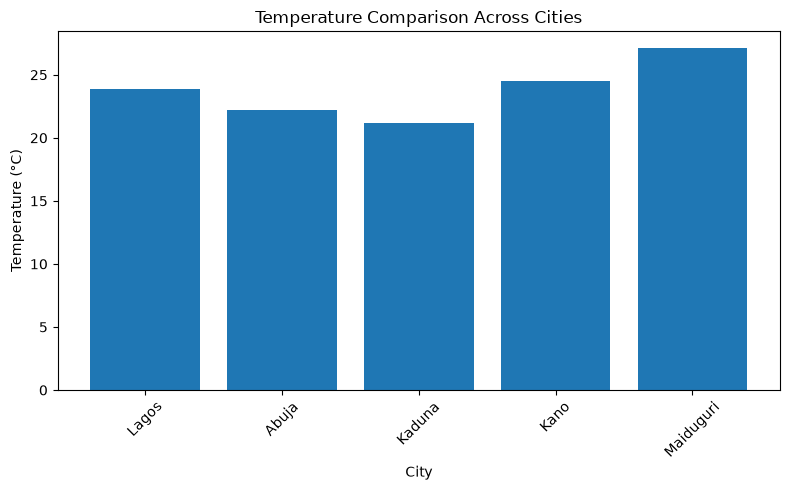

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    weather_df["City"],
    weather_df["Temperature_C"]
)

plt.title("Temperature Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

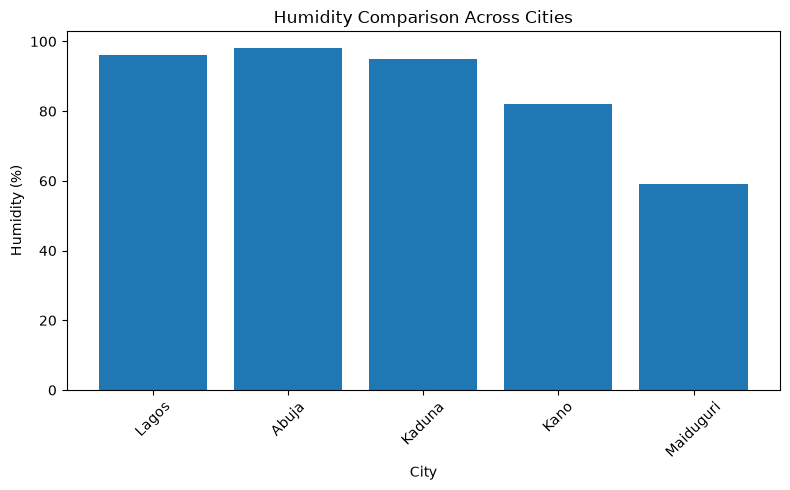

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    weather_df["City"],
    weather_df["Humidity_pct"]
)

plt.title("Humidity Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Humidity (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()



## 6. Key Findings

In [ ]:
print("Average Temperature:", round(weather_df["Temperature_C"].mean(), 2), "°C")
print("Average Humidity:", round(weather_df["Humidity_pct"].mean(), 2), "%")
print("Average Wind Speed:", round(weather_df["Wind_Speed_mps"].mean(), 2), "m/s")

Average Temperature: 23.78 °C
Average Humidity: 86.0 %
Average Wind Speed: 2.07 m/s


In [ ]:
weather_df.describe()

,Temperature_C,Humidity_pct,Wind_Speed_mps,Date_Time
count,5.000000,5.000000,5.000000,5
mean,23.778000,86.000000,2.068000,2026-08-18 23:06:06.200000
min,21.210000,59.000000,0.920000,2026-08-18 23:05:01
25%,22.230000,82.000000,1.360000,2026-08-18 23:06:20
50%,23.850000,95.000000,1.590000,2026-08-18 23:06:22
75%,24.510000,96.000000,3.060000,2026-08-18 23:06:23
max,27.090000,98.000000,3.410000,2026-08-18 23:06:25
std,2.263917,16.355427,1.099168,NaN


In [ ]:
weather_df["Weather_Condition"].value_counts()

Weather_Condition
overcast clouds     3
scattered clouds    1
broken clouds       1
Name: count, dtype: int64